In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
%matplotlib inline 
sns.set(style="ticks")

## Загрузка и первичный анализ данных

In [13]:
data = pd.read_csv('pizza_sales.csv', sep=",")

In [14]:
# размер набора данных
data.shape

(48620, 12)

In [15]:
# типы колонок
data.dtypes

pizza_id             float64
order_id             float64
pizza_name_id         object
quantity             float64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

In [16]:
# проверим есть ли пропущенные значения
data.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [17]:
# Первые 5 строк датасета
data.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [18]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 48620


## Кодирование категориальных признаков

In [19]:
data.drop(['pizza_id', 'order_id', "pizza_name_id"], axis=1, inplace=True)

In [20]:
data['order_date'] = data['order_date'].str.replace('-', '/')
data['order_date'] = pd.to_datetime(data['order_date'], format='%d/%m/%Y')
data['year'] = data['order_date'].dt.year
data['month'] = data['order_date'].dt.month
data['day'] = data['order_date'].dt.day
data.drop('order_date', axis=1, inplace=True)

In [21]:
data['order_time'] = pd.to_datetime(data['order_time'], format='%H:%M:%S')
data['order_hour'] = data['order_time'].dt.hour
data.drop('order_time', axis=1, inplace=True)

In [22]:
size_mapping = {'S': 0, 'M': 1, 'L': 2, 'XL': 3, 'XXL': 4}
category_mapping = {'Classic': 0, 'Veggie': 1, 'Supreme': 2, 'Chicken': 3}

In [23]:
data['pizza_size_encoded'] = data['pizza_size'].map(size_mapping)
data['pizza_category_encoded'] = data['pizza_category'].map(category_mapping)
data.drop(['pizza_size', 'pizza_category'], axis=1, inplace=True)

In [24]:
data['pizza_name_encoded'] = pd.factorize(data['pizza_name'])[0]
data.drop(['pizza_ingredients', 'pizza_name'], axis=1, inplace=True)

In [25]:
data.head()

,quantity,unit_price,total_price,year,month,day,order_hour,pizza_size_encoded,pizza_category_encoded,pizza_name_encoded
0,1.0,13.25,13.25,2015,1,1,11,1,0,0
1,1.0,16.00,16.00,2015,1,1,11,1,0,1
2,1.0,18.50,18.50,2015,1,1,11,2,1,2
3,1.0,20.75,20.75,2015,1,1,11,2,2,3
4,1.0,16.00,16.00,2015,1,1,11,1,1,4


## Разделение выборки на тестовую и обучающую

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = data.drop('total_price', axis=1)  # Признаки (все кроме целевой)
y = data['total_price']                # Целевая переменная

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% на тест
    random_state=42,    # для воспроизводимости
    shuffle=True        # перемешиваем данные перед разделением
)

## Обучение ансамблевых моделей

### 1) Стекинг

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from heamy.dataset import Dataset
from heamy.estimator import Regressor
from heamy.pipeline import ModelsPipeline

In [65]:
# Качество отдельных моделей
def val_mae(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = mean_absolute_error(y_test, y_pred)
    print(model.__class__.__name__)
    print('MAE={}'.format(result))
    return result

print("=" * 50)
print("ОТДЕЛЬНЫЕ МОДЕЛИ")
print("=" * 50)

results_single = {}
for model in [
    LinearRegression(),
    DecisionTreeRegressor(random_state=10),
    RandomForestRegressor(n_estimators=50, random_state=10)
]:
    mae = val_mae(model)
    results_single[model.__class__.__name__] = mae
    print('==========================')
    print()

ОТДЕЛЬНЫЕ МОДЕЛИ
LinearRegression
MAE=0.12297921217689083

DecisionTreeRegressor
MAE=0.0025452488687858835

RandomForestRegressor
MAE=0.0016422254216393107



In [66]:
# Ручная реализация стекинга
def stacking_models(base_models, meta_model, X_train, y_train, X_test, k=5):
    """
    base_models: список базовых моделей
    meta_model: мета-модель
    k: количество фолдов для кросс-валидации
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    
    # Для хранения предсказаний
    train_stack = np.zeros((X_train.shape[0], len(base_models)))
    test_stack = np.zeros((X_test.shape[0], len(base_models)))
    
    for i, model in enumerate(base_models):
        test_preds = np.zeros((X_test.shape[0], k))
        
        for j, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model_clone = model.__class__(**model.get_params())
            model_clone.fit(X_tr, y_tr)
            
            train_stack[val_idx, i] = model_clone.predict(X_val)
            test_preds[:, j] = model_clone.predict(X_test)
        
        test_stack[:, i] = test_preds.mean(axis=1)
    
    # Обучаем мета-модель
    meta_model.fit(train_stack, y_train)
    final_pred = meta_model.predict(test_stack)
    
    return final_pred

# Базовые модели
base_models = [
    LinearRegression(),
    DecisionTreeRegressor(random_state=10, max_depth=5),
    RandomForestRegressor(n_estimators=50, random_state=10)
]

# Мета-модели для экспериментов
meta_lr = LinearRegression()
meta_rf = RandomForestRegressor(n_estimators=50, random_state=10)

In [67]:
# Эксперимент 1: Tree + LR -> LR
base_2models = [base_models[1], base_models[0]]
pred1 = stacking_models(base_2models, LinearRegression(), X_train, y_train, X_test, k=5)
mae1 = mean_absolute_error(y_test, pred1)
print(f"Эксперимент 1 (Tree+LR -> LR): MAE = {mae1:.4f}")

Эксперимент 1 (Tree+LR -> LR): MAE = 0.0894


In [68]:
# Эксперимент 2: Tree + LR -> RF
pred2 = stacking_models(base_2models, RandomForestRegressor(n_estimators=50, random_state=10), 
                        X_train, y_train, X_test, k=5)
mae2 = mean_absolute_error(y_test, pred2)
print(f"Эксперимент 2 (Tree+LR -> RF): MAE = {mae2:.4f}")

Эксперимент 2 (Tree+LR -> RF): MAE = 0.0014


In [69]:
# Эксперимент 3: Tree + LR + RF -> LR
pred3 = stacking_models(base_models, LinearRegression(), X_train, y_train, X_test, k=5)
mae3 = mean_absolute_error(y_test, pred3)
print(f"Эксперимент 3 (Tree+LR+RF -> LR): MAE = {mae3:.4f}")

Эксперимент 3 (Tree+LR+RF -> LR): MAE = 0.0155


In [70]:
# Эксперимент 4: Tree + LR + RF -> RF
pred4 = stacking_models(base_models, RandomForestRegressor(n_estimators=50, random_state=10), 
                        X_train, y_train, X_test, k=5)
mae4 = mean_absolute_error(y_test, pred4)
print(f"Эксперимент 4 (Tree+LR+RF -> RF): MAE = {mae4:.4f}")

Эксперимент 4 (Tree+LR+RF -> RF): MAE = 0.0016


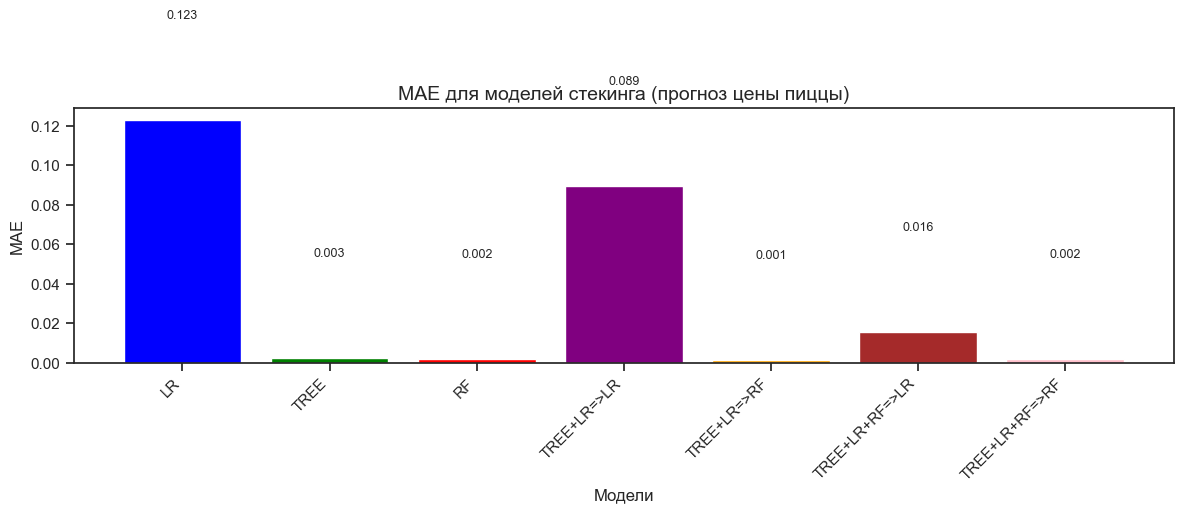

In [71]:
# Результаты
array_labels = ['LR', 'TREE', 'RF', 'TREE+LR=>LR', 'TREE+LR=>RF', 'TREE+LR+RF=>LR', 'TREE+LR+RF=>RF']
array_mae = [
    results_single['LinearRegression'],
    results_single['DecisionTreeRegressor'],
    results_single['RandomForestRegressor'],
    mae1, mae2, mae3, mae4
]

# Визуализация
def vis_models_quality(mae_scores, labels, title):
    plt.figure(figsize=(12, 6))
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink']
    bars = plt.bar(range(len(mae_scores)), mae_scores, color=colors)
    plt.xticks(range(len(mae_scores)), labels, rotation=45, ha='right')
    plt.ylabel('MAE', fontsize=12)
    plt.xlabel('Модели', fontsize=12)
    plt.title(title, fontsize=14)
    
    for bar, value in zip(bars, mae_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

vis_models_quality(array_mae, array_labels, 'MAE для моделей стекинга (прогноз цены пиццы)')

In [72]:
# Лучшая модель
best_idx = np.argmin(array_mae)
print("=" * 50)
print("ЛУЧШАЯ МОДЕЛЬ СТЕКИНГА:")
print("=" * 50)
print(f"Модель: {array_labels[best_idx]}")
print(f"MAE: {array_mae[best_idx]:.4f}")

ЛУЧШАЯ МОДЕЛЬ СТЕКИНГА:
Модель: TREE+LR=>RF
MAE: 0.0014


### 2) Многослойный персептрон

In [77]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

In [78]:
# Стандартизация данных для нейронной сети
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучаем MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),  # два скрытых слоя: 100 и 50 нейронов
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=10,
    early_stopping=True,
    validation_fraction=0.1
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

# Оценка качества
print("=" * 50)
print("МНОГОСЛОЙНЫЙ ПЕРСЕПТРОН (MLP)")
print("=" * 50)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_mlp)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_mlp):.4f}")
print(f"R²: {r2_score(y_test, y_pred_mlp):.4f}")

МНОГОСЛОЙНЫЙ ПЕРСЕПТРОН (MLP)
RMSE: 0.1265
MAE: 0.0479
R²: 0.9992


### 3) COMBI + RIA из семейства МГУА

In [30]:
from gmdh import Combi, Multi, Mia, Ria
from gmdh import split_data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [31]:
# Подготовка данных (используем уже готовые X_train, X_test, y_train, y_test)
# Преобразуем в numpy array если нужно
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
y_test_np = y_test.values if hasattr(y_test, 'values') else y_test

In [32]:
# ============================================
# ЛИНЕЙНЫЙ МЕТОД: COMBI (комбинаторный)
# ============================================
# COMBI перебирает все возможные комбинации признаков и выбирает лучшую

print("=" * 60)
print("МОДЕЛЬ COMBI (комбинаторный алгоритм)")
print("=" * 60)

# Обучаем COMBI
combi_model = Combi()
combi_model.fit(X_train_np, y_train_np)

# Предсказание
y_pred_combi = combi_model.predict(X_test_np)

# Оценка качества
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_np, y_pred_combi)):.4f}")
print(f"MAE: {mean_absolute_error(y_test_np, y_pred_combi):.4f}")
print(f"R²: {r2_score(y_test_np, y_pred_combi):.4f}")

# Вывод полученного полинома
print("\nНайденный полином:")
print(combi_model.get_best_polynomial())

МОДЕЛЬ COMBI (комбинаторный алгоритм)
RMSE: 0.5575
MAE: 0.1214
R²: 0.9845

Найденный полином:
y = 16.6809*x1 + 1.0137*x2 - 1.58882e-05*x4 + 0.0139*x7 + 0.0189*x8 - 0.0003*x9 - 16.9419


In [33]:
# ============================================
# НЕЛИНЕЙНЫЙ МЕТОД: RIA (релаксационный итеративный алгоритм)
# ============================================
# RIA - модификация MIA с релаксационным механизмом

print("=" * 60)
print("МОДЕЛЬ RIA (релаксационный итеративный алгоритм)")
print("=" * 60)

ria_model = Ria()
ria_model.fit(X_train_np, y_train_np)

# Предсказание
y_pred_ria = ria_model.predict(X_test_np)

# Оценка качества
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_np, y_pred_ria)):.4f}")
print(f"MAE: {mean_absolute_error(y_test_np, y_pred_ria):.4f}")
print(f"R²: {r2_score(y_test_np, y_pred_ria):.4f}")

print("\nНайденный полином:")
print(ria_model.get_best_polynomial())

МОДЕЛЬ RIA (релаксационный итеративный алгоритм)
RMSE: 0.0000
MAE: 0.0000
R²: 1.0000

Найденный полином:
f1 = 1.19413e-14*x1 - 9.5165e-16*x2 + x1*x2 - 8.34827e-16*x1^2 - 2.43786e-15*x2^2 - 4.76492e-15
y = - 1.45579e-16*x5 + f1 + 4.40759e-17*x5*f1 + 1.27618e-16*x5^2 - 1.82219e-15*f1^2 - 1.02827e-12


## Оценка качества моделей

In [73]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import AdaBoostRegressor

In [79]:
# Список моделей для сравнения (3 модели: Стекинг, MLP, GMDH)
models = {
    'Стекинг (Stacking)': None,
    'Многослойный персептрон (MLP)': None,
    'МГУА (GMDH)': None
}

# Получаем предсказания для каждой модели
# Для стекинга - используем pred3 (Tree+LR+RF -> LR)
stacking_pred = pred3

# Для MLP
mlp_pred = y_pred_mlp

# Для GMDH (COMBI)
gmdh_pred = y_pred_combi

# Оценка качества
results = []

# Стекинг
results.append({
    'Модель': 'Стекинг (Stacking)',
    'RMSE': np.sqrt(mean_squared_error(y_test, stacking_pred)),
    'MAE': mean_absolute_error(y_test, stacking_pred),
    'R²': r2_score(y_test, stacking_pred)
})

# MLP
results.append({
    'Модель': 'Многослойный персептрон (MLP)',
    'RMSE': np.sqrt(mean_squared_error(y_test, mlp_pred)),
    'MAE': mean_absolute_error(y_test, mlp_pred),
    'R²': r2_score(y_test, mlp_pred)
})

# GMDH
results.append({
    'Модель': 'МГУА (GMDH)',
    'RMSE': np.sqrt(mean_squared_error(y_test, gmdh_pred)),
    'MAE': mean_absolute_error(y_test, gmdh_pred),
    'R²': r2_score(y_test, gmdh_pred)
})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                       Модель     RMSE      MAE       R²
           Стекинг (Stacking) 0.093512 0.015521 0.999563
Многослойный персептрон (MLP) 0.126511 0.047884 0.999200
                  МГУА (GMDH) 0.557458 0.121392 0.984472


C:\Users\mfnnx\AppData\Local\Temp\ipykernel_1396\754244690.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(results_df['Модель'], rotation=15, ha='right')
C:\Users\mfnnx\AppData\Local\Temp\ipykernel_1396\754244690.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(results_df['Модель'], rotation=15, ha='right')
C:\Users\mfnnx\AppData\Local\Temp\ipykernel_1396\754244690.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[2].set_xticklabels(results_df['Модель'], rotation=15, ha='right')


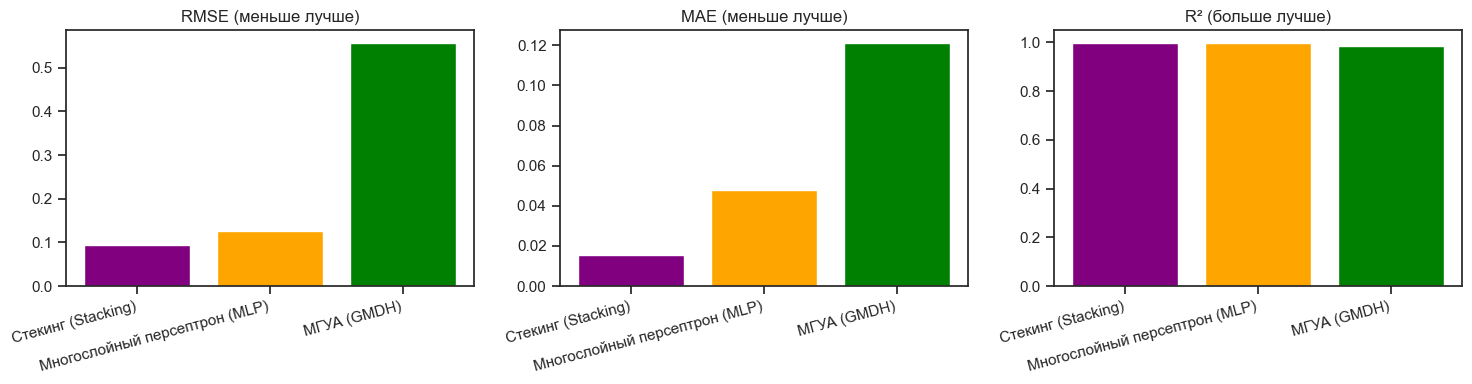

In [80]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE
axes[0].bar(results_df['Модель'], results_df['RMSE'], color=['purple', 'orange', 'green'])
axes[0].set_title('RMSE (меньше лучше)')
axes[0].set_xticklabels(results_df['Модель'], rotation=15, ha='right')

# MAE
axes[1].bar(results_df['Модель'], results_df['MAE'], color=['purple', 'orange', 'green'])
axes[1].set_title('MAE (меньше лучше)')
axes[1].set_xticklabels(results_df['Модель'], rotation=15, ha='right')

# R²
axes[2].bar(results_df['Модель'], results_df['R²'], color=['purple', 'orange', 'green'])
axes[2].set_title('R² (больше лучше)')
axes[2].set_xticklabels(results_df['Модель'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

In [81]:
# Вывод лучшей модели
best_model = results_df.loc[results_df['R²'].idxmax()]
print("=" * 50)
print("ЛУЧШАЯ МОДЕЛЬ (по R²):")
print("=" * 50)
print(f"Модель: {best_model['Модель']}")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"MAE: {best_model['MAE']:.4f}")
print(f"R²: {best_model['R²']:.4f}")

ЛУЧШАЯ МОДЕЛЬ (по R²):
Модель: Стекинг (Stacking)
RMSE: 0.0935
MAE: 0.0155
R²: 0.9996
